In [1]:
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
import torch_geometric.transforms as T
from torch_geometric.transforms import FixedPoints, KNNGraph, RadiusGraph
# from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from tqdm import tqdm
import wandb
from collections import defaultdict

import os
import os.path as osp

import sys
sys.path.append('src/')
from interface_dataset import InterfaceDataset
from transform import DivideByHeight, CenterViaPBC, FourierEmbeddings

sys.path.append('model/')
from PointNet import PointNet

In [2]:
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: fluffy-melon (fluffy-melon-airi). Use `wandb login --relogin` to force relogin


True

---

In [3]:
dataset = InterfaceDataset(root=osp.join('data/InterfaceDataset'))

In [4]:
config = {
    'points': 512,
    'knn_num': 6,
    'batch_size': 32,
    'lr': 1e-3,
    'epochs': 20
}

In [5]:
dataset.transform = T.Compose([
    CenterViaPBC(),
    DivideByHeight(),
    # FourierEmbeddings()
    FixedPoints(num=config['points']),
    KNNGraph(k=config['knn_num']),
    # RadiusGraph(r=0.1),
])

<function matplotlib.pyplot.show(close=None, block=None)>

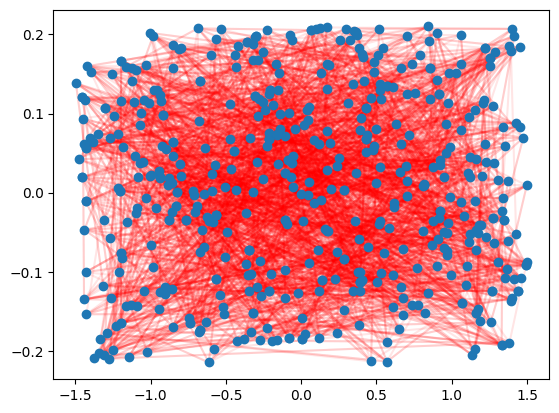

In [6]:
i = 0
pos = dataset[i].pos
edge_index = dataset[i].edge_index
x = 0
y = 2

for id in range(dataset[0].edge_index.size()[1]):
    i = edge_index[0, id]
    j = edge_index[1, id]
    plt.plot([pos[i, x], pos[j, x]], [pos[i, y], pos[j, y]], color='red', alpha=0.1, zorder=1)

plt.scatter(pos[:, x], pos[:, y], zorder=2)
plt.show

In [7]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

In [8]:
batch_size = config['batch_size']

train_loader = DataLoader(train_dataset.indices, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset.indices, batch_size=batch_size)

In [9]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [10]:
model = PointNet(num_classes=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
criterion = torch.nn.CrossEntropyLoss()

In [11]:
def train():
    model.train()

    total_loss = 0
    for data_indices in tqdm(train_loader, desc='Train'):
        data = Batch.from_data_list(dataset[data_indices]).to(device)

        optimizer.zero_grad()
        logits = model(data.pos, data.edge_index, data.batch)
        loss = criterion(logits, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs

    return total_loss / len(train_loader.dataset)

In [12]:
@torch.no_grad()
def test():
    model.eval()

    total_correct = 0
    for data_indices in tqdm(test_loader, desc='Test'):
        data = Batch.from_data_list(dataset[data_indices]).to(device)

        logits = model(data.pos, data.edge_index, data.batch)
        pred = logits.argmax(dim=-1)
        total_correct += int((pred == data.y).sum())

    return total_correct / len(test_loader.dataset)

In [13]:
metrics = defaultdict(list)

In [14]:
run = wandb.init(
    project="Panda-NN"
)

In [17]:
%%wandb

epochs = config['epochs']
for epoch in range(1, epochs+1):
    step_metrics = defaultdict()
    print(f'Epoch: {epoch:02d}')
    loss = train()
    test_acc = test()
    print(f'Loss: {loss:.4f}, Test Acc: {test_acc:.4f}')

    step_metrics['loss'] = loss
    step_metrics['accuracy'] = test_acc

    for key, item in step_metrics.items():
        metrics[key].append(item)

    run.log(
        dict(step_metrics),
        step=epoch
    )


Epoch: 01


Test:  90%|█████████ | 391/433 [00:38<00:04,  8.52it/s]

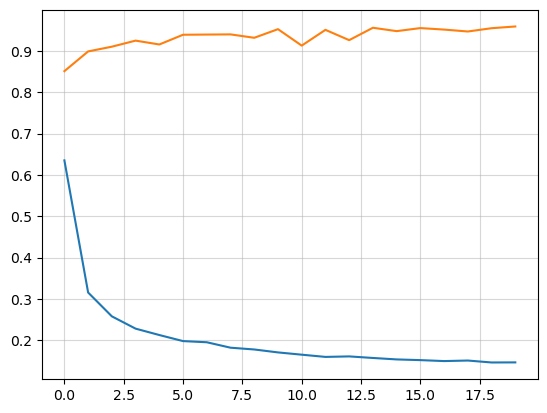

In [16]:
plt.grid(alpha=0.5)
plt.plot(Loss_train)
plt.plot(Loss_test)

In [11]:
torch.save(model.state_dict(), 'pointnet_1024.pt')